# Customer Retention & Churn Analysis

## Objective
Analyze customer data to identify churn patterns, understand retention drivers, and provide actionable recommendations to reduce customer churn and improve customer lifetime value.


## Import Libraries and Load Dataset

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Overview

In [10]:
df.info()
df.describe()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Data Cleaning

In [11]:

# Fix TotalCharges datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values
df.isnull().sum()

# Drop missing values
df.dropna(inplace=True)

## Plot Styling

In [14]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.rcParams['figure.figsize'] = (10, 6)

# Consistent colors
colors = {'Yes': '#E15759', 'No': '#4E79A7'}

## Churn Rate

In [15]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
churn_rate = churn_rate.round(2)

print("Churn Rate (%):")
print(churn_rate)

Churn Rate (%):
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


## Churn rate by contract

In [16]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


## Churn Distribution

C:\Users\Monwabisi05\AppData\Local\Temp\ipykernel_16060\2527085402.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


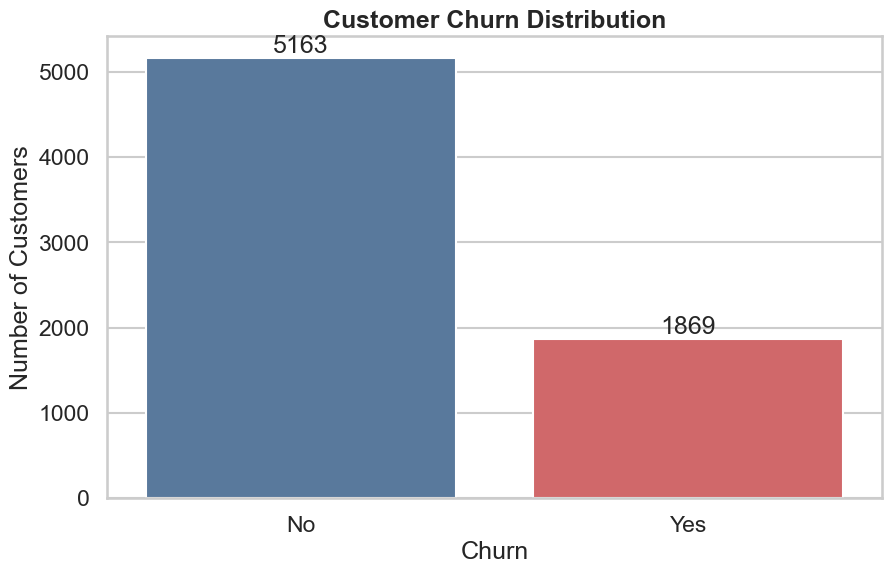

In [17]:
ax = sns.countplot(
    data=df,
    x='Churn',
    palette=colors
)

plt.title("Customer Churn Distribution", fontweight='bold')
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.show()

Insight: Approximately 26% of customers have churned.

## Contract Type vs Churn

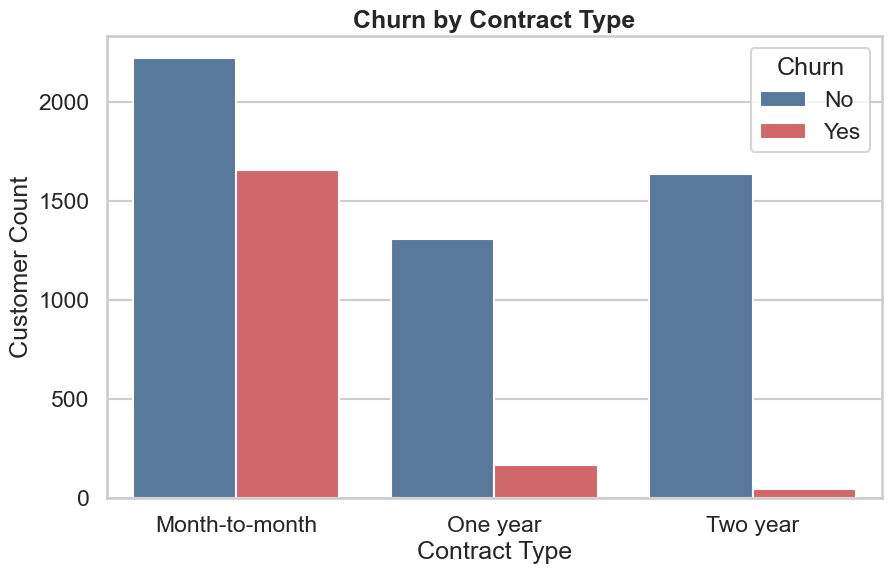

In [18]:
sns.countplot(
    data=df,
    x='Contract',
    hue='Churn',
    palette=colors
)

plt.title("Churn by Contract Type", fontweight='bold')
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.legend(title="Churn")

plt.show()

Insight:
Customers on month-to-month contracts show significantly higher churn compared to those on one-year or two-year contracts.
This suggests that lack of long-term commitment increases the likelihood of customer churn.

Recommendation:
Encourage long-term contracts through discounts or loyalty incentives.

## Tenure vs Churn (CUSTOMER LIFETIME)

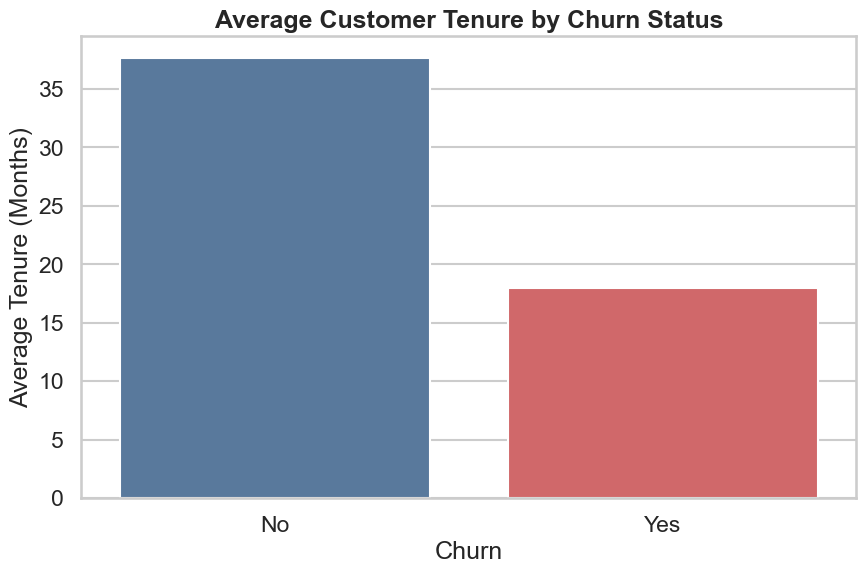

In [21]:
tenure_avg = df.groupby('Churn')['tenure'].mean().reset_index()

sns.barplot(
    data=tenure_avg,
    x='Churn',
    y='tenure',
    hue='Churn',
    palette=colors,
    legend=False
)

plt.title("Average Customer Tenure by Churn Status", fontweight='bold')
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")

plt.show()

Insight: Customers who churn have a significantly lower average tenure compared to those who stay.This shows that customers are most likely to leave early in their lifecycle.

Recommendation: Focus on improving early customer experience and onboarding to reduce churn.

## Monthly Charges vs Churn

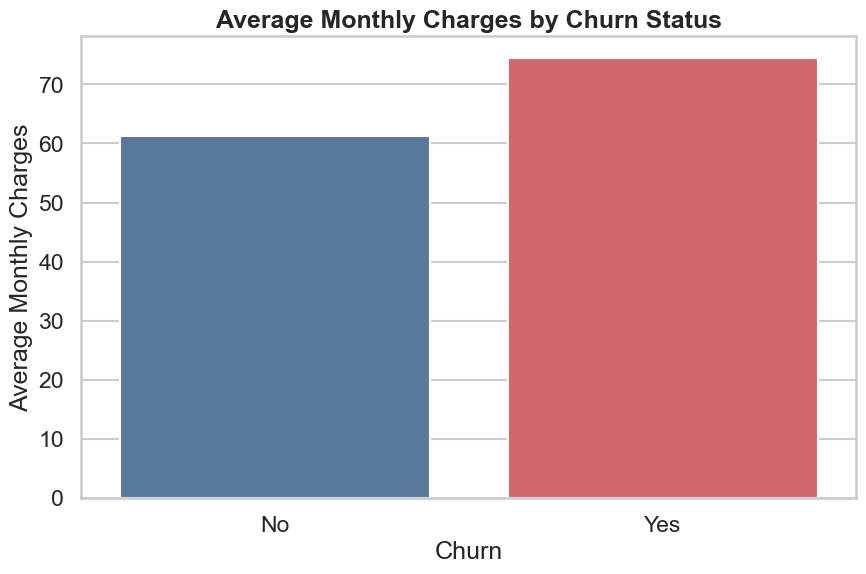

In [22]:
charges_avg = df.groupby('Churn')['MonthlyCharges'].mean().reset_index()

sns.barplot(
    data=charges_avg,
    x='Churn',
    y='MonthlyCharges',
    hue='Churn',
    palette=colors,
    legend=False
)

plt.title("Average Monthly Charges by Churn Status", fontweight='bold')
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")

plt.show()

Insight: Customers who churn tend to have higher average monthly charges compared to those who stay. This suggests that pricing may influence customer decisions to leave.

Recommendation: Review pricing strategy and ensure customers perceive sufficient value for higher-priced plans.

## Internet Service vs Churn

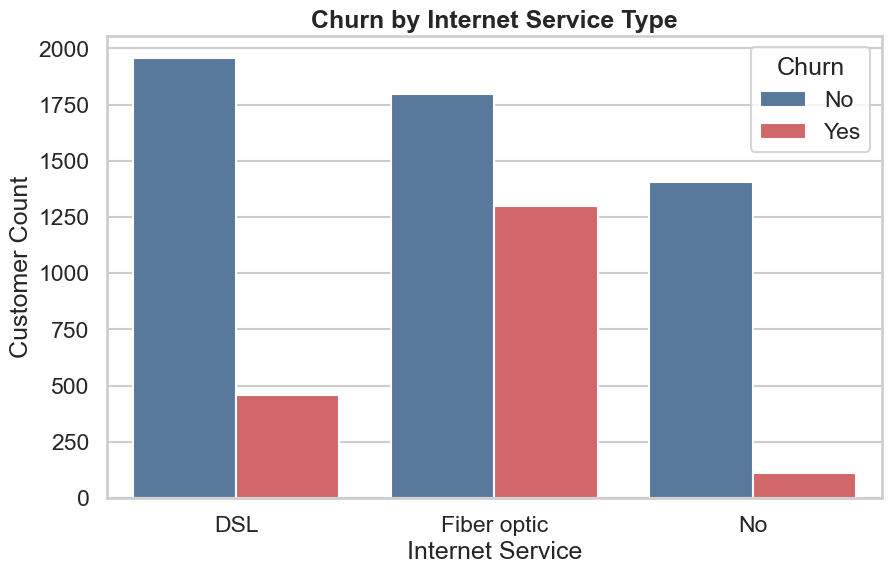

In [23]:
sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn',
    palette=colors
)

plt.title("Churn by Internet Service Type", fontweight='bold')
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")

plt.show()

Insight: Customers using fiber optic services show higher churn rates.This may indicate higher expectations or dissatisfaction with service quality.

## Payment Method vs Churn

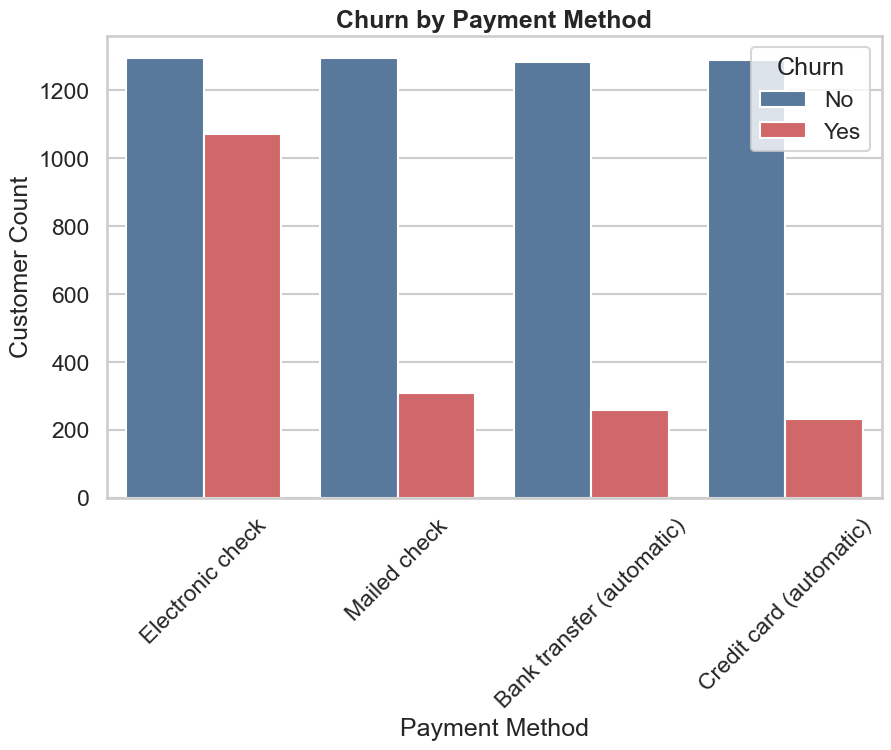

In [24]:
sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn',
    palette=colors
)

plt.title("Churn by Payment Method", fontweight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)

plt.show()

Insight: Customers using electronic check have higher churn rates.This may indicate lower commitment or higher friction in payment experience.

## Tech Support vs Churn

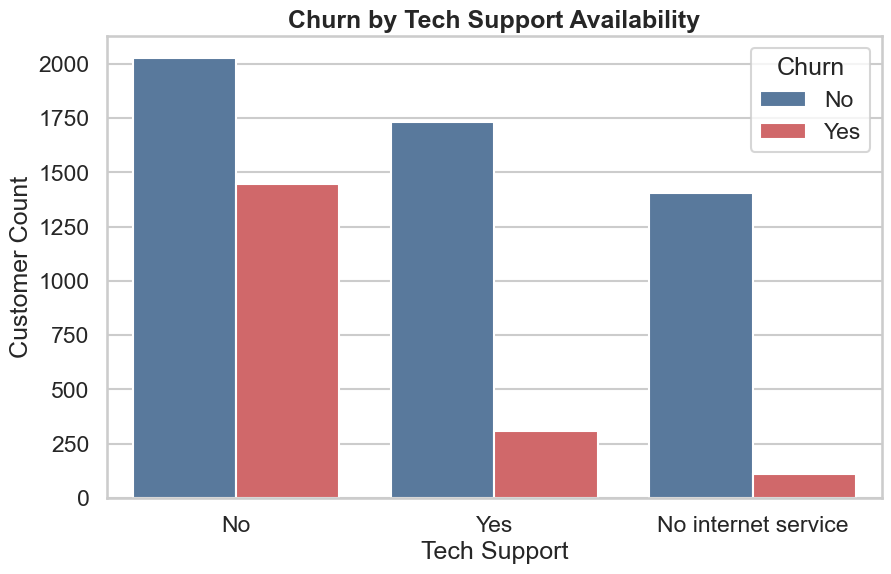

In [25]:
sns.countplot(
    data=df,
    x='TechSupport',
    hue='Churn',
    palette=colors
)

plt.title("Churn by Tech Support Availability", fontweight='bold')
plt.xlabel("Tech Support")
plt.ylabel("Customer Count")

plt.show()

Insight: Customers without tech support are significantly more likely to churn compared to those who have access to tech support.This suggests that lack of customer support leads to frustration, unresolved issues, and ultimately customer loss.

Recommendation: Improve access to tech support for all customers and proactively assist customers who are not using support features. 

## Customer Churn Risk: Monthly Charges vs Tenure

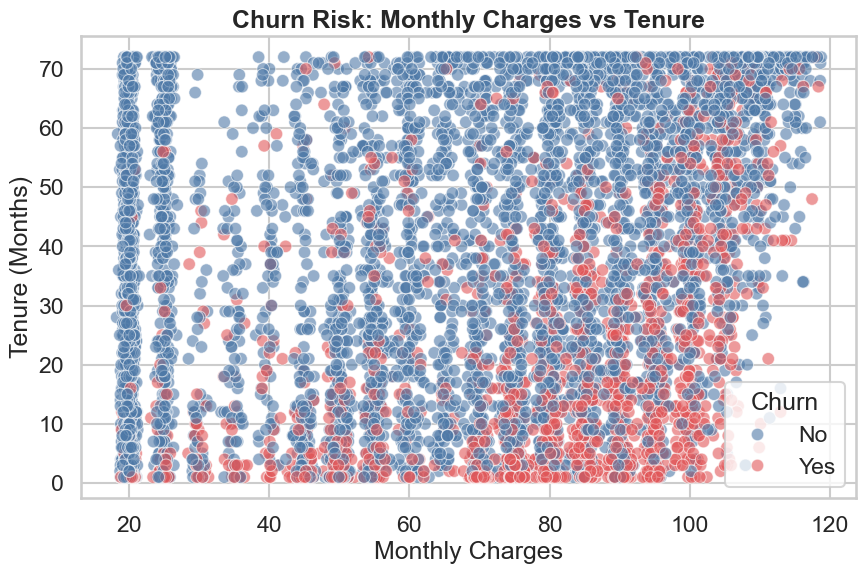

In [26]:
sns.scatterplot(
    data=df,
    x='MonthlyCharges',
    y='tenure',
    hue='Churn',
    palette=colors,
    alpha=0.6
)

plt.title("Churn Risk: Monthly Charges vs Tenure", fontweight='bold')
plt.xlabel("Monthly Charges")
plt.ylabel("Tenure (Months)")
plt.legend(title="Churn")

plt.show()

Insight: Customers with **high monthly charges and low tenure** are more likely to churn.This indicates that new customers who are paying more are at a higher risk of leaving early, possibly due to unmet expectations or perceived lack of value.
 

## Key Insights

- High churn rate (~26%) indicates retention challenges
- Month-to-month contracts have the highest churn
- New customers (low tenure) are more likely to leave
- Higher monthly charges increase churn likelihood
- Fiber optic users show higher churn behavior
- Electronic check users churn more frequently

## Priority Actions

1. Reduce churn in month-to-month customers (highest impact)
2. Improve onboarding for new customers (early churn risk)
3. Review pricing for high-charge customers

## Business Recommendations
- Promote long-term contracts with incentives
- Improve onboarding experience for new customers
- Review pricing strategies to reduce churn risk
- Enhance service quality for high-churn segments
- Optimize payment systems to improve customer experience